In [1]:

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

In [2]:
#get the dataset
data = pd.read_csv('../_data/Actresses_1670-1700.csv')
data

,Actress,Year,Play,Dramatist,Role,Type,Generic markers
0,Elizabeth Barry,1675,Alcibiades,Thomas Otway,Draxilla,maid,NaN
1,Elizabeth Barry,1676,Abdelazar,Aphra Behn,Leonora,young girl,NaN
2,Elizabeth Barry,1676,The Wrangling Lovers,Edward Ravenscroft,Elvira,young girl,NaN
3,Elizabeth Barry,1676,Tom Essence,Thomas Rawlins,Theodocia,young girl,NaN
4,Elizabeth Barry,1676,Madam Fickle,Thomas Durfey,Constantiana,young girl,NaN
...,...,...,...,...,...,...,...
497,Nell Gwyn,1668,The Mulberry Garden,Charles Sedley,Olivia,young girl,NaN
498,Nell Gwyn,1668,An Evening's Love,John Dryden,Donna Jacintha,young girl,NaN
499,Nell Gwyn,1668,The Damoiselles a la Mode,Richard Flecknoe,Lysette,maid,NaN
500,Nell Gwyn,1669,Tyrannick Love,John Dryden,Valeria,young girl,NaN


In [3]:
# remove the Types that have less than 10 occurrences
# get a list of the types
types = data['Type'].unique()
# get a count of the total number of occurrences of each type
type_counts = data['Type'].value_counts()

# create a DF called countDF that contains the type, the total (type counts), and the count of breeches and raped for each type
countDF = pd.DataFrame({'Type': type_counts.index, 'Total': type_counts.values})

# add columns for breeches and raped
countDF['breeches'] = 0
countDF['raped'] = 0

# for each type, get the count of breeches and raped in the data DF, adding it to countDF
for index, row in countDF.iterrows():
    # get the type
    type_ = row['Type']
    # get the count of breeches in the Generic markers column
    countDF.at[index, 'breeches'] = data[data['Type'] == type_]['Generic markers'].str.contains('breeches', na=False).sum()
    # get the count of raped in the Generic markers column
    countDF.at[index, 'raped'] = data[data['Type'] == type_]['Generic markers'].str.contains('raped', na=False).sum()



In [4]:
# occurrences of each type
type_counts = data['Type'].value_counts()

# create a DF called countDF that contains the type, the total (type counts), and the count of breeches and raped for each type
countDF = pd.DataFrame({'Type': type_counts.index, 'Total': type_counts.values})

# add columns for breeches and raped
countDF['breeches'] = 0
countDF['raped'] = 0

# for each type, get the count of breeches and raped in the data DF, adding it to countDF
for index, row in countDF.iterrows():
    # get the type
    type_ = row['Type']
    # get the count of breeches in the Generic markers column
    countDF.at[index, 'breeches'] = data[data['Type'] == type_]['Generic markers'].str.contains('breeches', na=False).sum()
    # get the count of raped in the Generic markers column
    countDF.at[index, 'raped'] = data[data['Type'] == type_]['Generic markers'].str.contains('raped', na=False).sum()



/tmp/ipykernel_8457/2646113114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Total', data=countDF2, palette='viridis')


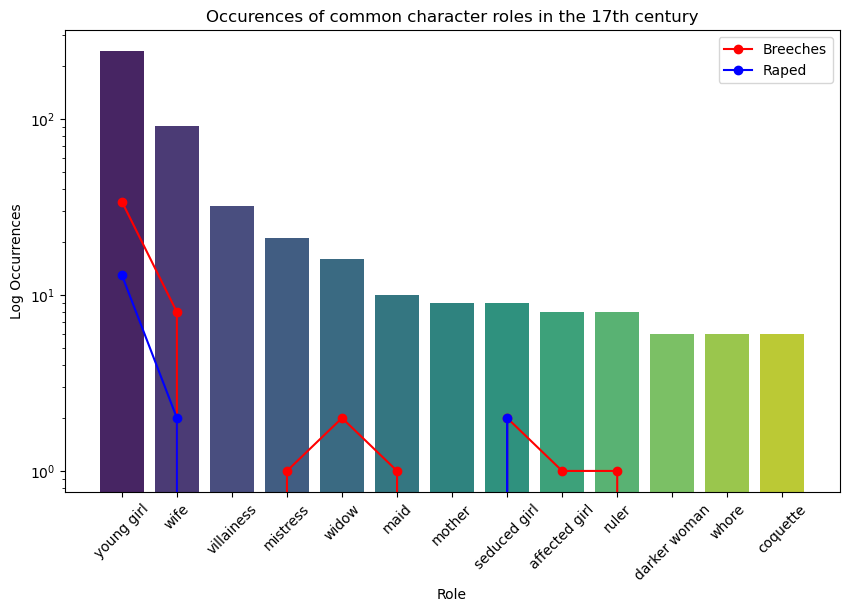

In [5]:
# create a new DF to store the those where the total is greater than 5
countDF2 = countDF[countDF['Total'] > 5]

# Plot a bar chart of the types and the total
plt.figure(figsize=(10, 6))
sns.barplot(x='Type', y='Total', data=countDF2, palette='viridis')
#Add a line chart for the breeches
plt.plot(countDF2['Type'], countDF2['breeches'], color='red', marker='o', label='Breeches')
#Add a line
plt.plot(countDF2['Type'], countDF2['raped'], color='blue', marker='o', label = 'Raped')
plt.yscale('log')
#tilt the x-axis labels
plt.xticks(rotation=45)
plt.legend()
plt.title('Occurences of common character roles in the 17th century')
plt.xlabel('Role')
plt.ylabel('Log Occurrences')
# save the plot
plt.savefig('../Visualizations/occurrences.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# get a lis of the unique plays
plays = data['Play'].unique()

# get a list of each unique actress
actresses = data['Actress'].unique()

# create a df that contins the number of connections between each two actresses
connections = pd.DataFrame(index=actresses, columns=actresses)

# for each play, get a list of the names of the actresses that has played in them 
for play in plays:
    actresses = data[data['Play'] == play]['Actress'].unique()
    # for each pair of actresses, add 1 to the number of connections between them
    for i in range(len(actresses)):
        for j in range(i + 1, len(actresses)):
            if pd.isna(connections.loc[actresses[i], actresses[j]]):
                connections.loc[actresses[i], actresses[j]] = 1
            else:
                connections.loc[actresses[i], actresses[j]] += 1
            if pd.isna(connections.loc[actresses[j], actresses[i]]):
                connections.loc[actresses[j], actresses[i]] = 1
            else:
                connections.loc[actresses[j], actresses[i]] += 1
#set the lower triangle of the connections matrix to 0
for i in range(len(connections)):
    for j in range(i):
        connections.iloc[i, j] = 0
connections

,Elizabeth Barry,Mary Betterton,Jane Rogers,Susannah Mountfort,Rebecca Marshall,Jane Long,Frances Maria Knight,Mary Lee,Mary (‘Moll’) Davis,Elizabeth Currer,Charlotte Butler,Anne Bracegirdle,Elizabeth Boutell,Nell Gwyn
Elizabeth Barry,NaN,13,1,10,1,NaN,5,11,NaN,8,5,29,3,NaN
Mary Betterton,0,NaN,1,2,NaN,11,2,20,4,6,1,3,NaN,NaN
Jane Rogers,0,0,NaN,15,NaN,NaN,16,1,NaN,1,NaN,4,NaN,NaN
Susannah Mountfort,0,0,0,NaN,NaN,NaN,24,3,NaN,4,6,11,2,NaN
Rebecca Marshall,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,5
Jane Long,0,0,0,0,0,NaN,NaN,3,5,NaN,NaN,NaN,NaN,NaN
Frances Maria Knight,0,0,0,0,0,0,NaN,2,NaN,2,3,10,1,NaN
Mary Lee,0,0,0,0,0,0,0,NaN,NaN,7,2,NaN,NaN,NaN
Mary (‘Moll’) Davis,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
Elizabeth Currer,0,0,0,0,0,0,0,0,0,NaN,3,1,NaN,NaN


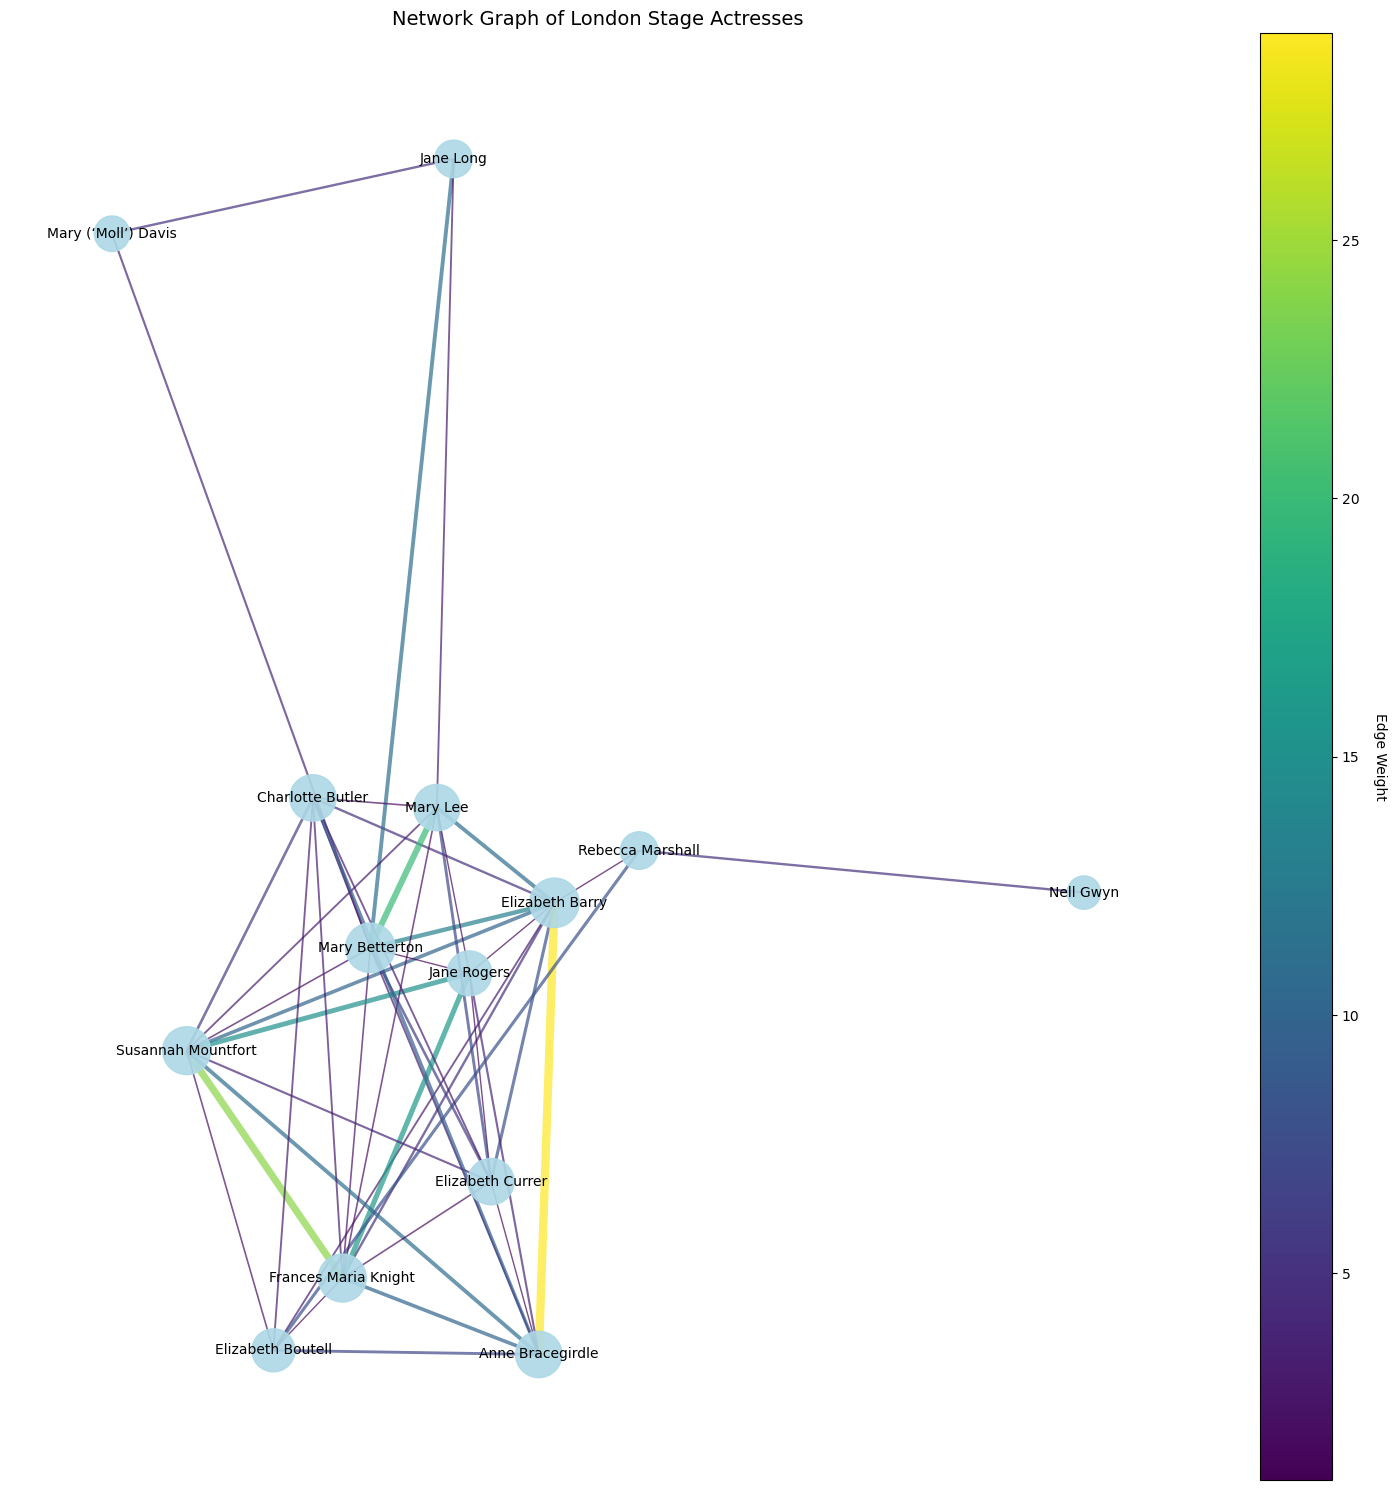

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  # Required for scaling
# turn on the interactive mode
plt.ion()
# Create graph
G = nx.Graph()

# Add nodes and edges with weights
for actress in connections.index:
    G.add_node(actress)

for i in range(len(connections.index)):
    for j in range(i + 1, len(connections.index)):
        weight = connections.iloc[i, j]
        if weight > 0:
            G.add_edge(connections.index[i], connections.index[j], weight=weight)

# Extract edge weights
weights = [G[u][v]['weight'] for u, v in G.edges()]

# Normalize and scale
norm = plt.Normalize(min(weights), max(weights))
cmap = plt.cm.viridis
edge_colors = [cmap(norm(w)) for w in weights]
scaled_weights = [1 + 5 * (w - min(weights)) / (max(weights) - min(weights)) for w in weights]
node_sizes = [500 + 1000 * nx.degree_centrality(G)[n] for n in G.nodes()]

# Use kamada_kawai_layout to reduce edge-node overlap
pos = nx.kamada_kawai_layout(G)

# Plotting
fig, ax = plt.subplots(figsize=(15, 15))
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color='lightblue', alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=scaled_weights, alpha=0.7)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_family='sans-serif')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(weights)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Edge Weight', rotation=270, labelpad=20)
cbar.ax.set_facecolor('none')

# Final touches
ax.set_title('Network Graph of London Stage Actresses', fontsize=14)
plt.axis('off')
plt.tight_layout()
fig.savefig('../Visualizations/ActressNetwork.png', dpi=300, bbox_inches='tight')
plt.show()




/tmp/ipykernel_8457/1527983790.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_connections = connections.fillna(0).astype(float)


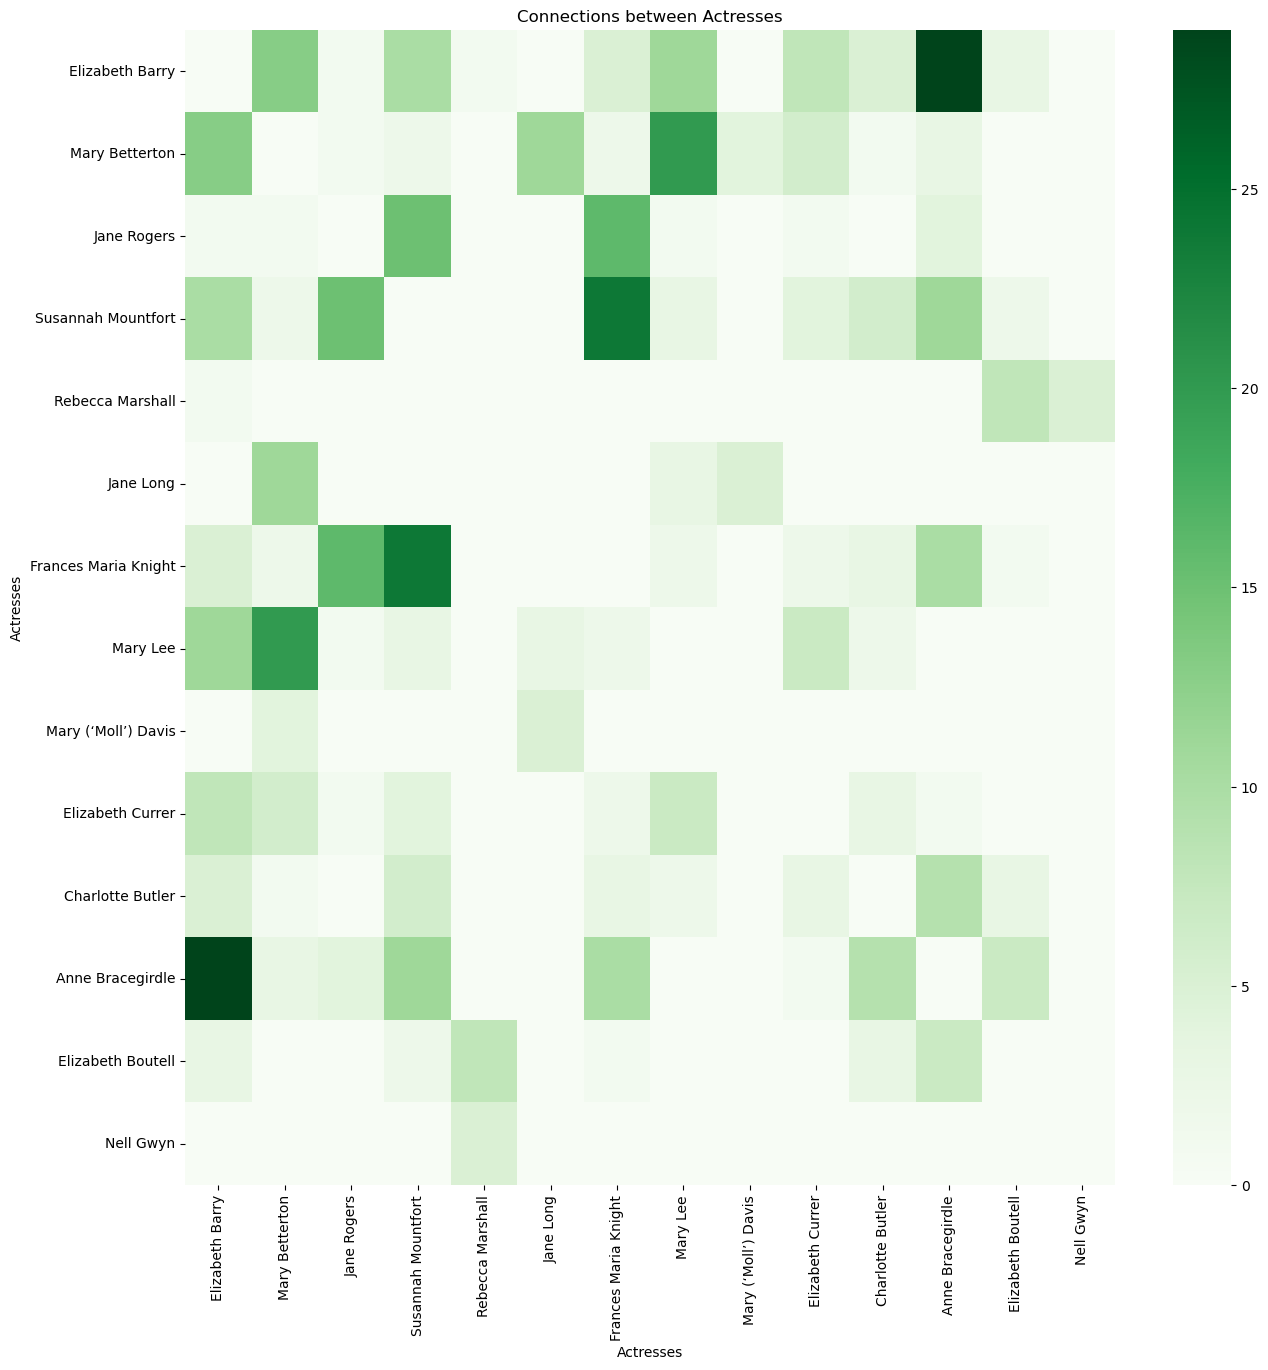

In [8]:


# Ensure the connections DataFrame contains only numeric data
numeric_connections = connections.fillna(0).astype(float)
# copy the upper tri into the lower tri
for i in range(len(numeric_connections)):
    for j in range(i):
        numeric_connections.iloc[i, j] = numeric_connections.iloc[j, i]

# Present a heatmap of the connections matrix
plt.figure(figsize=(15, 15))
sns.heatmap(numeric_connections, cmap='Greens', annot=False, cbar=True)
plt.title('Connections between Actresses')
plt.xlabel('Actresses')
plt.ylabel('Actresses')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.savefig('../Visualizations/ActressConnections.png', dpi=300, bbox_inches='tight')
plt.show()


In [9]:
import duckdb

Dramatist_Actress = duckdb.query('SELECT Dramatist, Actress, count(*) as count FROM data GROUP BY Dramatist, Actress HAVING count > 2 ORDER BY count DESC').df()

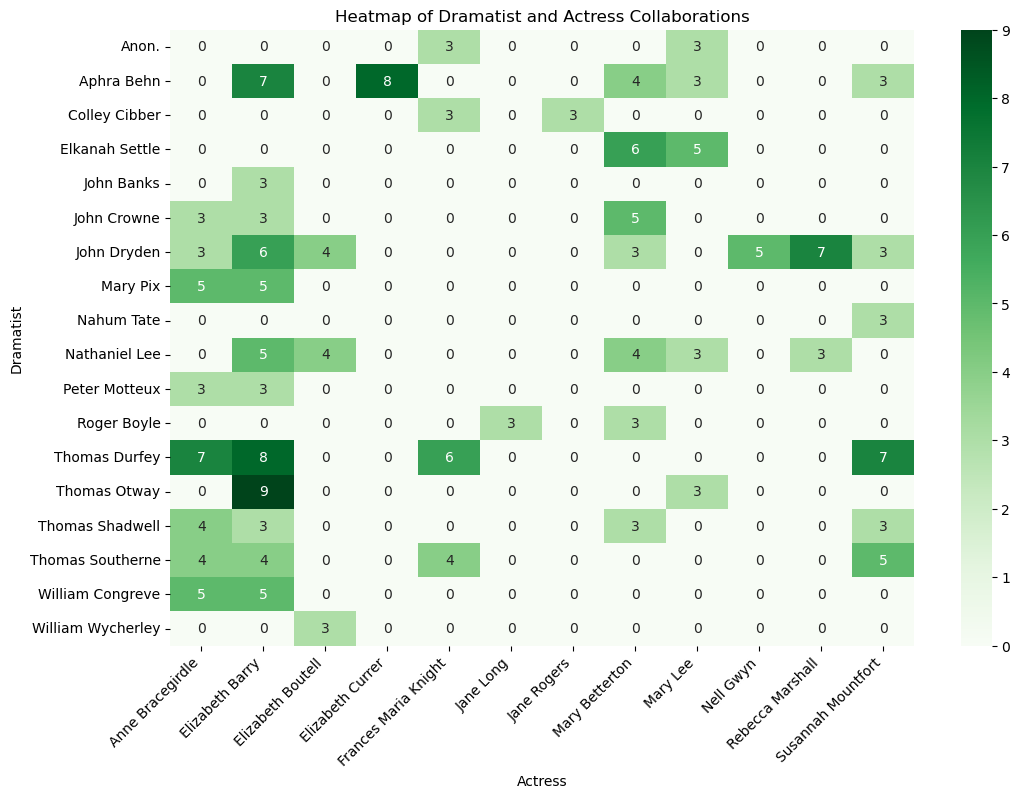

In [10]:
# Plot the Dramatist_Actress df as a heatmap
plt.figure(figsize=(12, 8))
heatmap_data = Dramatist_Actress.pivot_table(index='Dramatist', columns='Actress', values='count', fill_value=0)
sns.heatmap(heatmap_data, cmap='Greens', annot=True)
plt.title('Heatmap of Dramatist and Actress Collaborations')
plt.xlabel('Actress')
plt.ylabel('Dramatist')
# rotate the x-axis labels for better readability, but have the end of the labels match with the x-axis tick
plt.xticks(rotation=45, ha='right')
plt.savefig('../Visualizations/Dramatist_Actress_connections.png', dpi=300, bbox_inches='tight')
plt.show()


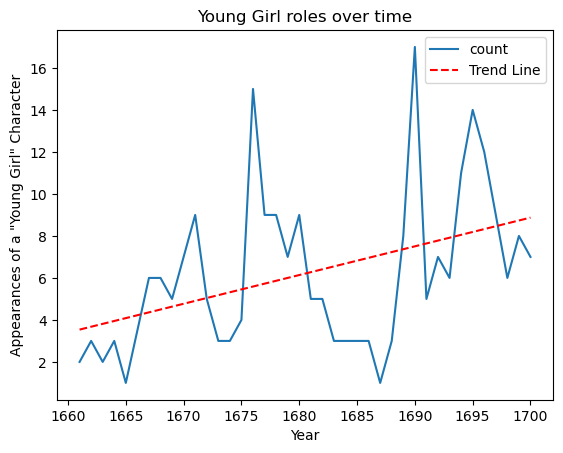

In [11]:
young_girl_year = duckdb.query("SELECT Year, count(*) as count FROM data WHERE Type = 'young girl' AND Year IS NOT NULL GROUP BY Year ORDER BY Year ASC").df()

young_girl_year.plot.line(x='Year', y='count')
plt.xlabel('Year')
plt.ylabel('Appearances of a "Young Girl" Character')
# Add a trend line
z = np.polyfit(young_girl_year['Year'], young_girl_year['count'], 1)
p = np.poly1d(z)
plt.plot(young_girl_year['Year'], p(young_girl_year['Year']), linestyle='--', color='red', label='Trend Line')
plt.legend()

plt.title('Young Girl roles over time')
# save the plot
plt.savefig('../Visualizations/YoungGirlRolesOverTime.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# For each actress, find the role they've done the most from 'Type' and return it as a table, storing the count as well

most_common_role = duckdb.query('SELECT Actress, Type, count(*) as count FROM data GROUP BY Actress, Type ORDER BY Actress, count DESC').df()


# for each type, find the actress that has done the most roles in that type
most_common_role = duckdb.query('SELECT Type, Actress, count(*) as count FROM data GROUP BY Type, Actress ORDER BY Type, count DESC').df()

# get the top for each type
most_common_role = most_common_role.groupby('Type').head(1)

# order by count
most_common_role = most_common_role.sort_values(by='count', ascending=False)
# get the top 10
most_common_role = most_common_role.head(10)

# remove country girl, affected girl, and darker woman
most_common_role = most_common_role[~most_common_role['Type'].isin(['country girl', 'affected girl', 'darker woman'])]

most_common_role


,Type,Actress,count
97,young girl,Anne Bracegirdle,52
83,wife,Elizabeth Barry,30
63,villainess,Elizabeth Barry,9
27,mistress,Elizabeth Barry,6
8,coquette,Susannah Mountfort,4
34,mother,Mary Betterton,4
74,widow,Frances Maria Knight,3


In [13]:
# Read the CSV file while skipping problematic rows
# The file is too large to add to the git repo, so if you need to run this code, please download the csv file from the link below and place it in the _data folder
# https://londonstagedatabase.uoregon.edu/
df = pd.read_csv("../_data/LondonStageFull.csv", on_bad_lines='skip')

theater_performances = duckdb.query("SELECT t_TheatreName, count(*) as theater_count FROM df WHERE e_EventDate > 16600000 AND e_EventDate < 17000000 GROUP BY t_TheatreName, e_TheatreId HAVING count(e_TheatreId) > 10 ORDER BY e_TheatreID").df()
theater_performances = theater_performances.iloc[1:]

# add a column for longitude and latitude
theater_performances['longitude'] = 0
theater_performances['latitude'] = 0

theater_performances

#This was used to generate the file theatre_count&location.csv, and then used in the map visualization
# longitude and latitude were added to the csv file manually, since the data was spread around old archives and not in a single file

/tmp/ipykernel_8457/4183485354.py:4: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../_data/LondonStageFull.csv", on_bad_lines='skip')


,t_TheatreName,theater_count,longitude,latitude
1,Whitehall or St. James's,367,0,0
2,Bartholomew Fair,48,0,0
3,"Bedford Gate, Charles Street",16,0,0
4,The (first) Drury Lane Theatre,491,0,0
5,"The City, London",39,0,0
6,The Cockpit in Drury Lane,14,0,0
7,Dorset Garden Theatre,1343,0,0
8,Drury Lane Theatre,1782,0,0
9,Drury Lane Theatre or Dorset Garden Theatre,153,0,0
10,Inner Temple,36,0,0
